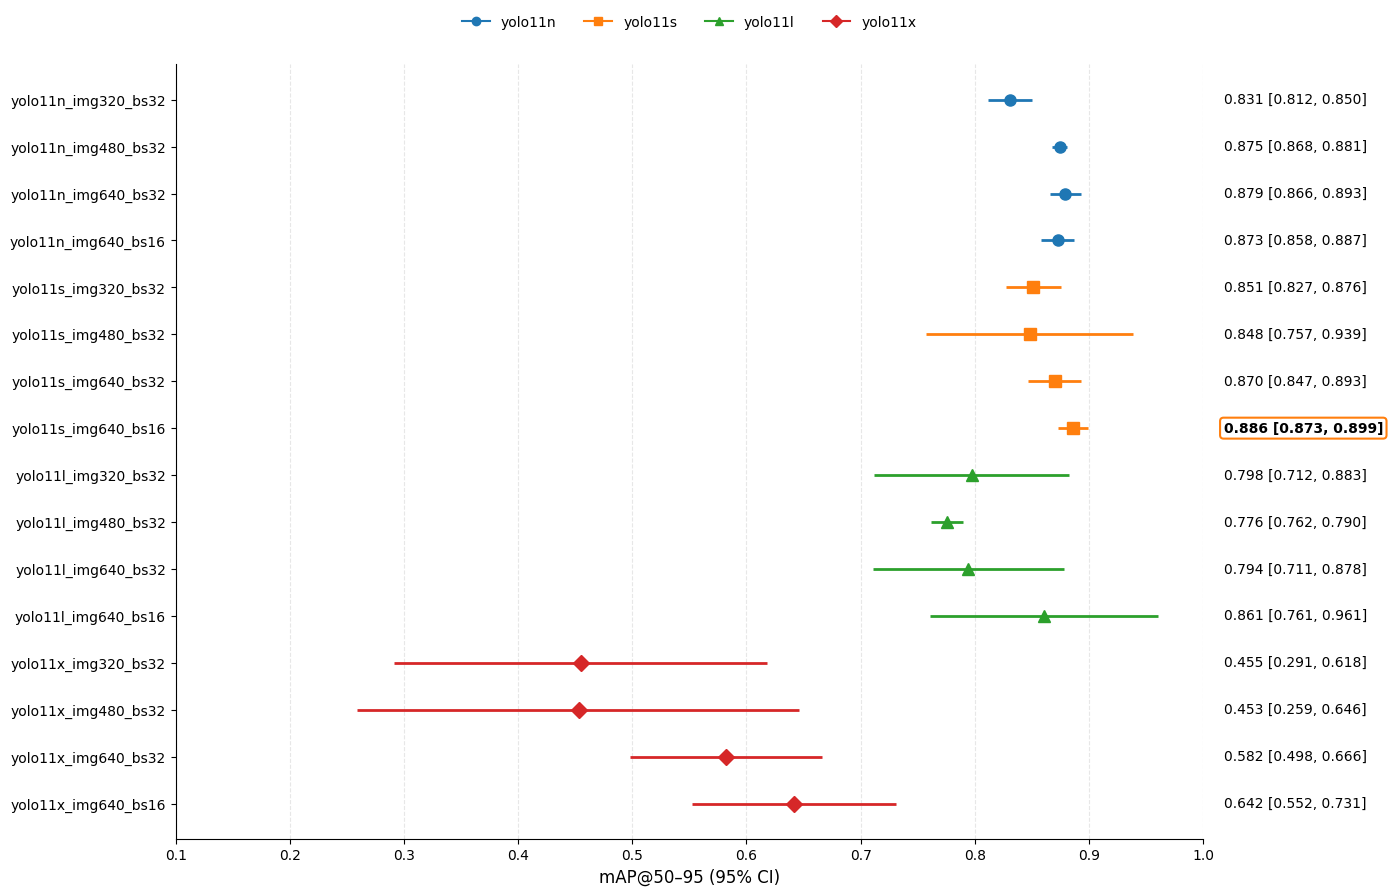

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# =========================
# DATOS
# =========================
rows = [
    ("yolo11n_img320_bs32", "yolo11n", 0.831, 0.812, 0.850),
    ("yolo11n_img480_bs32", "yolo11n", 0.875, 0.868, 0.881),
    ("yolo11n_img640_bs32", "yolo11n", 0.879, 0.866, 0.893),
    ("yolo11n_img640_bs16", "yolo11n", 0.873, 0.858, 0.887),

    ("yolo11s_img320_bs32", "yolo11s", 0.851, 0.827, 0.876),
    ("yolo11s_img480_bs32", "yolo11s", 0.848, 0.757, 0.939),
    ("yolo11s_img640_bs32", "yolo11s", 0.870, 0.847, 0.893),
    ("yolo11s_img640_bs16", "yolo11s", 0.886, 0.873, 0.899),

    ("yolo11l_img320_bs32", "yolo11l", 0.798, 0.712, 0.883),
    ("yolo11l_img480_bs32", "yolo11l", 0.776, 0.762, 0.790),
    ("yolo11l_img640_bs32", "yolo11l", 0.794, 0.711, 0.878),
    ("yolo11l_img640_bs16", "yolo11l", 0.861, 0.761, 0.961),

    ("yolo11x_img320_bs32", "yolo11x", 0.455, 0.291, 0.618),
    ("yolo11x_img480_bs32", "yolo11x", 0.453, 0.259, 0.646),
    ("yolo11x_img640_bs32", "yolo11x", 0.582, 0.498, 0.666),
    ("yolo11x_img640_bs16", "yolo11x", 0.642, 0.552, 0.731),
]

# =========================
# ESTILOS
# =========================
colors = {
    "yolo11n": "#1f77b4",
    "yolo11s": "#ff7f0e",
    "yolo11l": "#2ca02c",
    "yolo11x": "#d62728",
}

markers = {
    "yolo11n": "o",
    "yolo11s": "s",
    "yolo11l": "^",
    "yolo11x": "D",
}

# =========================
# PREPARAR DATOS
# =========================
labels = [r[0] for r in rows]
means = np.array([r[2] for r in rows])

# detectar mejor modelo
best_idx = np.argmax(means)

y = np.arange(len(rows))[::-1]

# =========================
# PLOT
# =========================
fig, ax = plt.subplots(figsize=(14, 9))

for i, (label, model, mean, low, high) in enumerate(rows):
    yy = y[i]

    ax.errorbar(
        mean,
        yy,
        xerr=[[mean - low], [high - mean]],
        fmt=markers[model],
        color=colors[model],
        markersize=8,
        linewidth=2,
    )

    # Texto fuera del eje
    ax.text(
        1.02,
        yy,
        f"{mean:.3f} [{low:.3f}, {high:.3f}]",
        transform=ax.get_yaxis_transform(),
        va="center",
        fontsize=10,
        fontweight="bold" if i == best_idx else "normal",
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="white",
            edgecolor=colors[model],
            linewidth=1.5,
        ) if i == best_idx else None,
    )

# =========================
# CONFIGURACIÓN
# =========================
ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=10)

ax.set_xlabel("mAP@50–95 (95% CI)", fontsize=12)

# escala adecuada
ax.set_xlim(0.10, 1.00)

ax.grid(axis="x", linestyle="--", alpha=0.3)

# Leyenda
for model in colors:
    ax.plot(
        [],
        [],
        marker=markers[model],
        color=colors[model],
        label=model,
        linestyle="-",
    )

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.08),
    ncol=4,
    frameon=False,
)

# limpieza
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# espacio derecha
plt.subplots_adjust(right=0.75)

plt.tight_layout()
plt.savefig("3_yolo_votacion.png", dpi=300, bbox_inches="tight")
plt.show()